<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kesembilan/blob/main/Praktikum_9_1_MG_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRAKTIKUM 9.1: PERBANDINGAN TEKNIK THRESHOLDING


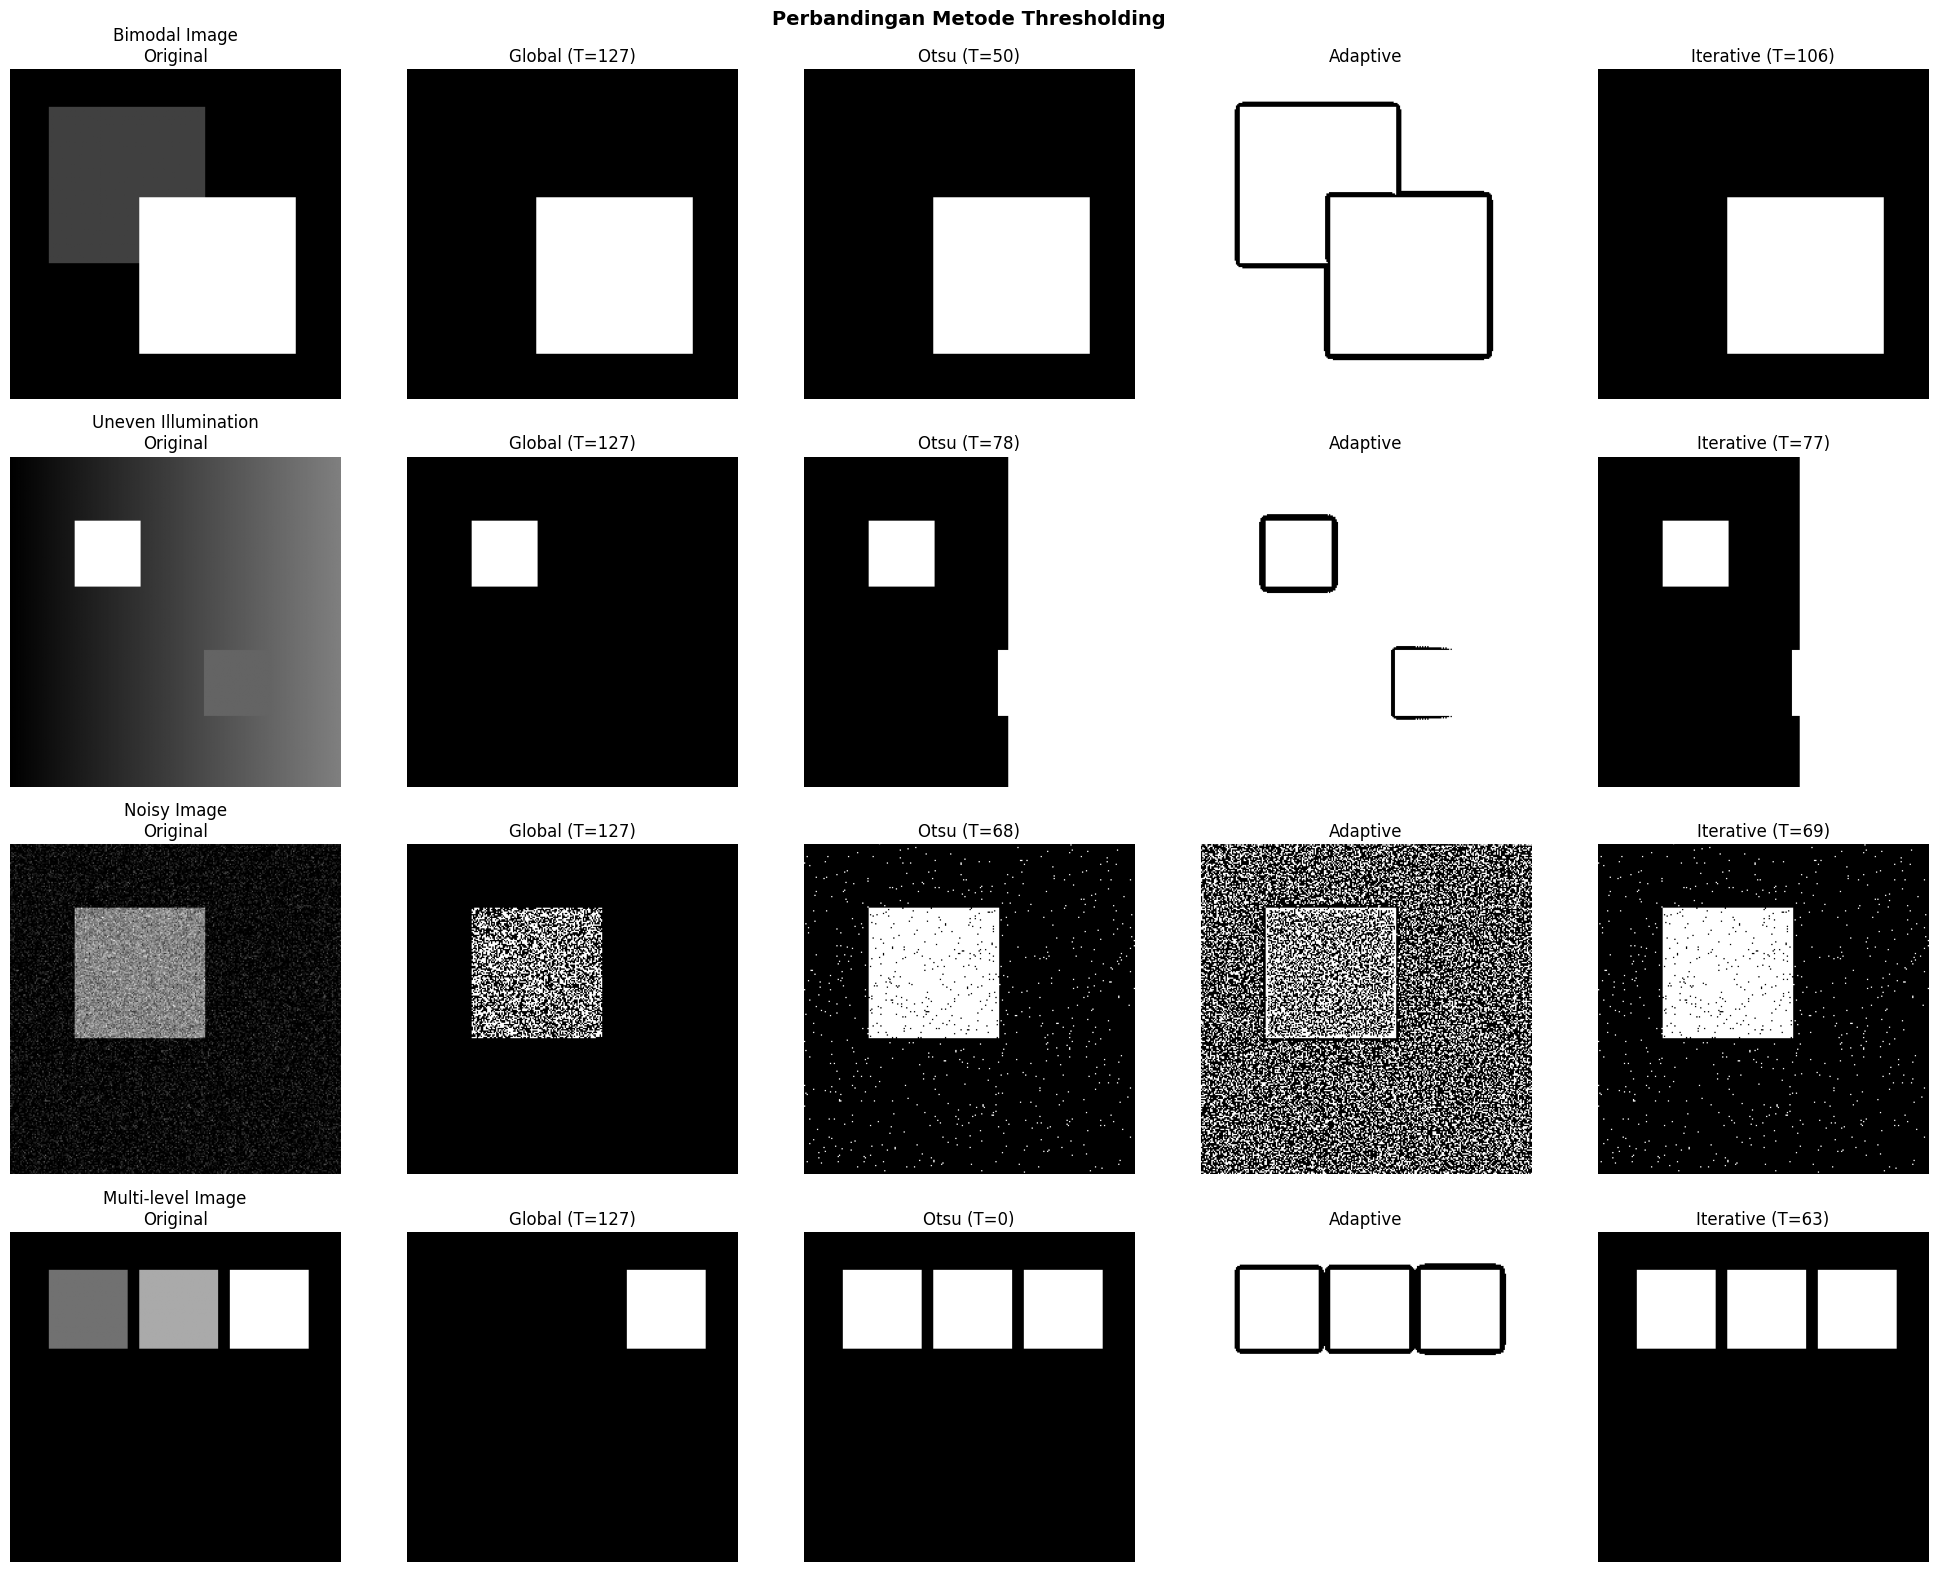


ANALISIS HISTOGRAM DAN THRESHOLD SELECTION
------------------------------------------------------------


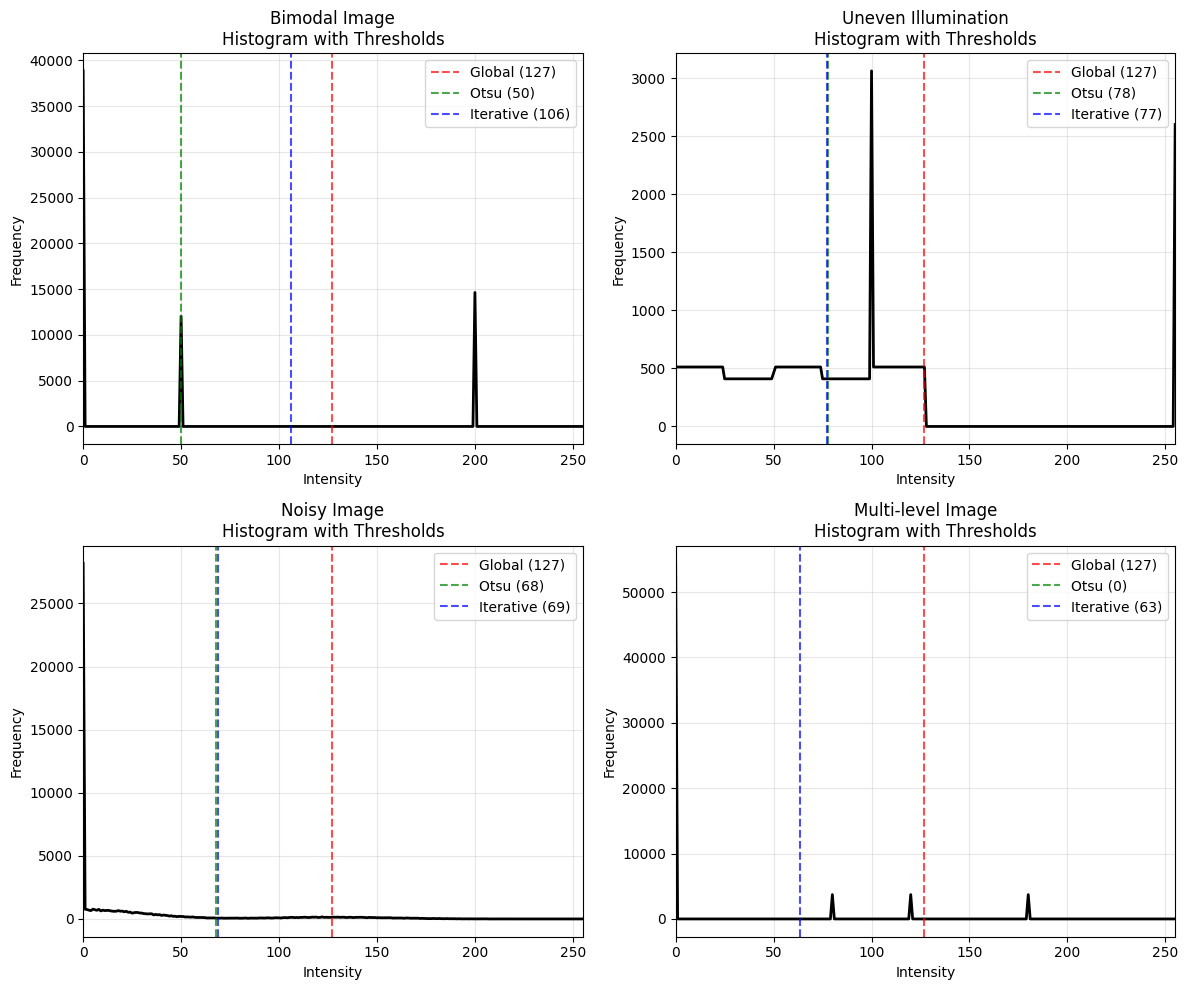


EVALUASI KUANTITATIF (DENGAN SIMULASI GROUND TRUTH)
----------------------------------------------------------------------
Method          Accuracy   Precision  Recall     F1-Score   IoU       
----------------------------------------------------------------------
Global          0.815      0.984      0.548      0.703      0.543     
Otsu            0.815      0.984      0.548      0.703      0.543     
Adaptive        0.448      0.420      0.985      0.589      0.417     
Iterative       0.815      0.984      0.548      0.703      0.543     


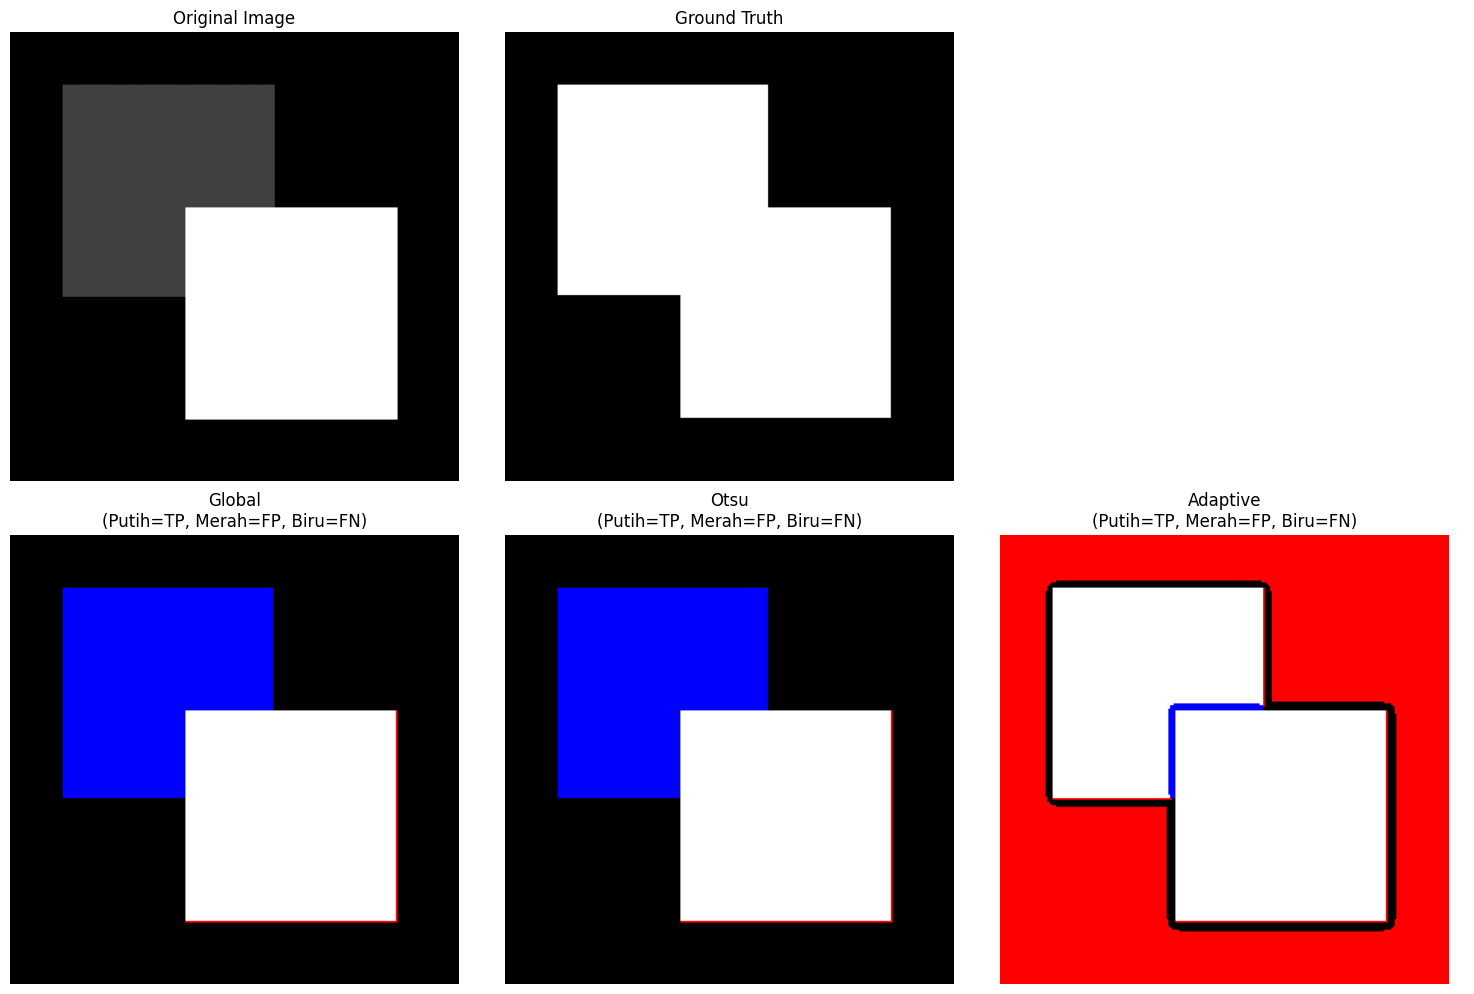


KESIMPULAN DAN REKOMENDASI
----------------------------------------

1. Global Thresholding:
   - Cocok untuk citra dengan kontras tinggi dan illumination uniform.
   - Sensitif terhadap uneven illumination dan noise.
   - Membutuhkan pemilihan threshold secara manual.

2. Otsu's Method:
   - Sepenuhnya otomatis; memaksimalkan variansi antar-kelas.
   - Optimal untuk citra dengan histogram bimodal.
   - Kurang efektif pada multi-modal atau uneven illumination.

3. Adaptive Thresholding:
   - Cocok untuk uneven illumination.
   - Robust terhadap variasi intensitas lokal.
   - Parameter block_size dan C perlu disesuaikan.

4. Iterative Thresholding:
   - Threshold otomatis melalui konvergensi mean foreground/background.
   - Cocok untuk distribusi intensitas yang jelas (bimodal).
   - Lebih mahal secara komputasi dibanding Otsu.
    


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def praktikum_9_1():
    """
    Perbandingan teknik thresholding: Global, Otsu, dan Adaptive
    """
    print("PRAKTIKUM 9.1: PERBANDINGAN TEKNIK THRESHOLDING")
    print("=" * 60)

    # ------------------------------------------------------------------ #
    #  1. Buat citra test                                                  #
    # ------------------------------------------------------------------ #
    def create_test_images():
        images = {}

        # Citra bimodal (ideal untuk thresholding)
        img_bimodal = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_bimodal, (30, 30),   (150, 150), 50,  -1)
        cv2.rectangle(img_bimodal, (100, 100), (220, 220), 200, -1)
        images['Bimodal Image'] = img_bimodal

        # Citra dengan uneven illumination
        img_uneven = np.zeros((256, 256), dtype=np.uint8)
        for i in range(256):
            img_uneven[:, i] = i // 2
        cv2.rectangle(img_uneven, (50, 50),   (100, 100), 255, -1)
        cv2.rectangle(img_uneven, (150, 150), (200, 200), 100, -1)
        images['Uneven Illumination'] = img_uneven

        # Citra dengan noise
        img_noisy = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_noisy, (50, 50), (150, 150), 128, -1)
        noise = np.random.normal(0, 30, img_noisy.shape)
        img_noisy = np.clip(img_noisy.astype(float) + noise, 0, 255).astype(np.uint8)
        images['Noisy Image'] = img_noisy

        # Citra dengan multiple intensity levels
        img_multi = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_multi, (30,  30), (90,  90),  80,  -1)
        cv2.rectangle(img_multi, (100, 30), (160, 90),  120, -1)
        cv2.rectangle(img_multi, (170, 30), (230, 90),  180, -1)
        images['Multi-level Image'] = img_multi

        return images

    # ------------------------------------------------------------------ #
    #  2. Metode thresholding                                              #
    # ------------------------------------------------------------------ #
    def apply_global_threshold(image, T=127):
        """Global thresholding dengan nilai T tetap."""
        _, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)
        return binary

    def apply_otsu_threshold(image):
        """Otsu's automatic thresholding."""
        _, binary = cv2.threshold(image, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binary

    def apply_adaptive_threshold(image, block_size=11, C=2):
        """Adaptive thresholding (Gaussian weighted)."""
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) \
               if len(image.shape) == 3 else image
        binary = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            block_size, C
        )
        return binary

    def apply_iterative_threshold(image, max_iter=100, tolerance=1.0):
        """
        Iterative threshold selection (isodata-style).
        Returns: (binary_image, final_threshold)
        """
        T = float(np.mean(image))

        for _ in range(max_iter):
            foreground = image[image > T]
            background = image[image <= T]

            if len(foreground) == 0 or len(background) == 0:
                break

            T_new = (np.mean(foreground) + np.mean(background)) / 2.0

            if abs(T_new - T) < tolerance:
                T = T_new
                break

            T = T_new

        _, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)
        return binary, T          # <- selalu (ndarray, float)

    # ------------------------------------------------------------------ #
    #  3. Terapkan semua metode ke setiap citra                           #
    # ------------------------------------------------------------------ #
    test_images = create_test_images()
    results = {}

    for name, image in test_images.items():
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) \
               if len(image.shape) == 3 else image.copy()

        global_binary             = apply_global_threshold(gray, 127)
        otsu_binary               = apply_otsu_threshold(gray)
        adaptive_binary           = apply_adaptive_threshold(gray, 11, 2)
        iterative_binary, T_iter  = apply_iterative_threshold(gray)   # BUG FIX: unpack correctly

        # Ambil nilai threshold Otsu
        T_otsu, _                 = cv2.threshold(gray, 0, 255,
                                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        results[name] = {
            'original':   gray,
            'global':     global_binary,
            'otsu':       otsu_binary,
            'adaptive':   adaptive_binary,
            'iterative':  iterative_binary,
            'T_otsu':     float(T_otsu),
            'T_iter':     float(T_iter),          # BUG FIX: sudah float, bukan tuple
        }

    # ------------------------------------------------------------------ #
    #  4. Visualisasi hasil thresholding                                  #
    # ------------------------------------------------------------------ #
    n_images = len(results)
    fig, axes = plt.subplots(n_images, 5, figsize=(20, 4 * n_images))

    # Pastikan axes selalu 2-D walaupun n_images == 1
    if n_images == 1:
        axes = axes[np.newaxis, :]

    for idx, (name, result) in enumerate(results.items()):
        axes[idx, 0].imshow(result['original'], cmap='gray')
        axes[idx, 0].set_title(f'{name}\nOriginal')
        axes[idx, 0].axis('off')

        methods = ['global', 'otsu', 'adaptive', 'iterative']
        titles  = [
            'Global (T=127)',
            f'Otsu (T={result["T_otsu"]:.0f})',
            'Adaptive',
            f'Iterative (T={result["T_iter"]:.0f})',
        ]

        for col, (method, title) in enumerate(zip(methods, titles), start=1):
            axes[idx, col].imshow(result[method], cmap='gray')
            axes[idx, col].set_title(title)
            axes[idx, col].axis('off')

    plt.suptitle('Perbandingan Metode Thresholding', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    #  5. Histogram dengan garis threshold                                #
    # ------------------------------------------------------------------ #
    print("\nANALISIS HISTOGRAM DAN THRESHOLD SELECTION")
    print("-" * 60)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    for idx, (name, result) in enumerate(list(results.items())[:4]):
        hist = cv2.calcHist([result['original']], [0], None, [256], [0, 256])
        axes[idx].plot(hist, 'k-', linewidth=2)
        axes[idx].axvline(x=127,               color='r', linestyle='--',
                          label='Global (127)',                       alpha=0.7)
        axes[idx].axvline(x=result['T_otsu'],   color='g', linestyle='--',
                          label=f'Otsu ({result["T_otsu"]:.0f})',     alpha=0.7)
        axes[idx].axvline(x=result['T_iter'],   color='b', linestyle='--',
                          label=f'Iterative ({result["T_iter"]:.0f})', alpha=0.7)

        axes[idx].set_title(f'{name}\nHistogram with Thresholds')
        axes[idx].set_xlabel('Intensity')
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim([0, 255])

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    #  6. Evaluasi kuantitatif                                            #
    # ------------------------------------------------------------------ #
    print("\nEVALUASI KUANTITATIF (DENGAN SIMULASI GROUND TRUTH)")
    print("-" * 70)

    # Ground truth untuk bimodal image
    gt_bimodal = np.zeros((256, 256), dtype=np.uint8)
    gt_bimodal[30:150, 30:150]   = 1
    gt_bimodal[100:220, 100:220] = 1

    def calculate_metrics(binary, ground_truth):
        """Hitung metrik segmentasi (accuracy, precision, recall, F1, IoU)."""
        binary       = (binary       > 0).astype(np.uint8)
        ground_truth = (ground_truth > 0).astype(np.uint8)

        tp = int(np.sum((binary == 1) & (ground_truth == 1)))
        fp = int(np.sum((binary == 1) & (ground_truth == 0)))
        fn = int(np.sum((binary == 0) & (ground_truth == 1)))
        tn = int(np.sum((binary == 0) & (ground_truth == 0)))

        accuracy  = (tp + tn) / (tp + tn + fp + fn) if (tp+tn+fp+fn) > 0 else 0
        precision = tp / (tp + fp)                   if (tp + fp)     > 0 else 0
        recall    = tp / (tp + fn)                   if (tp + fn)     > 0 else 0
        f1_score  = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0)
        iou       = tp / (tp + fp + fn)              if (tp+fp+fn)    > 0 else 0

        return dict(accuracy=accuracy, precision=precision,
                    recall=recall, f1_score=f1_score, iou=iou)

    bimodal_result = results['Bimodal Image']
    methods      = ['global', 'otsu', 'adaptive', 'iterative']
    method_names = ['Global', 'Otsu', 'Adaptive', 'Iterative']

    print(f"{'Method':<15} {'Accuracy':<10} {'Precision':<10} "
          f"{'Recall':<10} {'F1-Score':<10} {'IoU':<10}")
    print("-" * 70)

    for method, method_name in zip(methods, method_names):
        m = calculate_metrics(bimodal_result[method], gt_bimodal)
        print(f"{method_name:<15} {m['accuracy']:<10.3f} {m['precision']:<10.3f} "
              f"{m['recall']:<10.3f} {m['f1_score']:<10.3f} {m['iou']:<10.3f}")

    # ------------------------------------------------------------------ #
    #  7. Visualisasi error (TP / FP / FN)                               #
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    axes[0, 0].imshow(bimodal_result['original'], cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(gt_bimodal, cmap='gray')
    axes[0, 1].set_title('Ground Truth')
    axes[0, 1].axis('off')

    axes[0, 2].axis('off')   # kosong

    for idx, (method, method_name) in enumerate(zip(methods[:3], method_names[:3])):
        result_binary = (bimodal_result[method] > 0).astype(np.uint8)

        error_image = np.zeros((256, 256, 3), dtype=np.uint8)
        error_image[(result_binary == 1) & (gt_bimodal == 1)] = [255, 255, 255]  # TP
        error_image[(result_binary == 1) & (gt_bimodal == 0)] = [255,   0,   0]  # FP
        error_image[(result_binary == 0) & (gt_bimodal == 1)] = [  0,   0, 255]  # FN

        axes[1, idx].imshow(error_image)
        axes[1, idx].set_title(f'{method_name}\n(Putih=TP, Merah=FP, Biru=FN)')
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    #  8. Kesimpulan                                                      #
    # ------------------------------------------------------------------ #
    print("\nKESIMPULAN DAN REKOMENDASI")
    print("-" * 40)
    print("""
1. Global Thresholding:
   - Cocok untuk citra dengan kontras tinggi dan illumination uniform.
   - Sensitif terhadap uneven illumination dan noise.
   - Membutuhkan pemilihan threshold secara manual.

2. Otsu's Method:
   - Sepenuhnya otomatis; memaksimalkan variansi antar-kelas.
   - Optimal untuk citra dengan histogram bimodal.
   - Kurang efektif pada multi-modal atau uneven illumination.

3. Adaptive Thresholding:
   - Cocok untuk uneven illumination.
   - Robust terhadap variasi intensitas lokal.
   - Parameter block_size dan C perlu disesuaikan.

4. Iterative Thresholding:
   - Threshold otomatis melalui konvergensi mean foreground/background.
   - Cocok untuk distribusi intensitas yang jelas (bimodal).
   - Lebih mahal secara komputasi dibanding Otsu.
    """)

    return results


# ------------------------------------------------------------------ #
#  Entry point                                                         #
# ------------------------------------------------------------------ #
if __name__ == "__main__":
    thresholding_results = praktikum_9_1()